In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
import SEACells

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


In [3]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import fast_matrix_market as fmm

In [4]:
# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100

### Generate Anndata object from gene count matrix and annotation file 

In [5]:
import scanpy as sc
import scipy.io

In [6]:
# GE matrix 
ge_matrix="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_count.txt.gz"
# Metadata 
metadata="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_cell_annotation.csv.gz"
# Working directory 
WD="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/Seacells/"

In [7]:
# Replace 'data.mtx' with the path to your MatrixMarket file
matrix = fmm.mmread(ge_matrix)

In [8]:
# transpose matrix 
matrix = matrix.T

In [9]:
# convert COO to CSR or CSC sparse matrix
matrix = matrix.tocsr()

<1469111x55416 sparse matrix of type '<class 'numpy.int64'>'
	with 1217134367 stored elements in Compressed Sparse Row format>

In [10]:
adata = sc.AnnData(X=matrix)

In [12]:
# Gene annotations 
gene_annots = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_annotation.csv.gz"

# Read in gene_annots and clean up dataframe 
gene_annots = pd.read_csv(gene_annots)

,gene_id,gene_type,gene_short_name
0,ENSMUSG00000102693.2,TEC,4933401J01Rik
1,ENSMUSG00000064842.3,snRNA,Gm26206
2,ENSMUSG00000051951.6,protein_coding,Xkr4
3,ENSMUSG00000102851.2,processed_pseudogene,Gm18956
4,ENSMUSG00000103377.2,TEC,Gm37180


In [13]:
# now add gene_annots as gene annotations in the anndata object
adata.var = gene_annots

AnnData object with n_obs × n_vars = 1469111 × 55416
    var: 'gene_id', 'gene_type', 'gene_short_name'

In [14]:
# create anndata object from gene_matrix and metadata
metadata = pd.read_csv(metadata)
adata.obs = metadata

print("Done creating anndata object")

### Pre-processing

The following section describes basic pre-processing steps for scRNA-seq.

In [15]:
# Copy the counts to ".raw" attribute of the anndata since it is necessary for downstream analysis
# This step should be performed after filtering 
ad = adata
raw_ad = sc.AnnData(ad.X)
raw_ad.obs_names, raw_ad.var_names = ad.obs_names, ad.var_names
ad.raw = raw_ad

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [16]:
sc.pp.normalize_total(ad, target_sum=1e4)  # Normalize to 10,000 reads per cell

In [17]:
# Log transform
sc.pp.log1p(ad)

In [18]:
# Compute highly variable genes
sc.pp.highly_variable_genes(ad, n_top_genes=1500, flavor="seurat_v3") # "seurat_v3" is a method similar to Seurat v3, which can handle large datasets efficiently.

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [19]:
# Compute principal components - 
# Here we use 50 components. This number may also be selected by examining variance explaint
sc.tl.pca(ad, n_comps=50, use_highly_variable=True)

In [44]:
# Subset adata object to contain just two major cell types 
# Check how many cells are in each cell type
print(ad.obs['Main_cluster_name'].value_counts())

# let's just keep Hindbrain neurons 1 and Habenula neurons cells in subset ad object 
adata_subset = ad[ad.obs['Main_cluster_name'].isin(['Hindbrain neurons 1', 'Habenula neurons'])]
print(adata_subset)  

Main_cluster_name
Cerebellum granule neurons           477790
Cortical projection neurons 1        177274
Interbrain and midbrain neurons 1    154645
Interbrain and midbrain neurons 2    143349
Oligodendrocytes                     104514
Astrocytes                            66383
Striatal neurons 1                    56080
Cortical projection neurons 2         39036
OB neurons 1                          37258
Cerebellum interneurons               27566
Interneurons 1                        27475
Oligodendrocyte progenitor cells      22718
Endothelial cells                     20362
Dentate gyrus neurons                 20110
Microglia                             16879
Interneurons 2                        16370
Purkinje neurons                      10439
Bergmann glia                          9478
Vascular leptomeningeal cells          8277
OB neurons 2                           6823
Choroid plexus epithelial cells        4379
Cortical projection neurons 3          4219
Hindbrain neur

### Running SEACells

As a rule of thumb, we recommended choosing one metacell for every 75 single-cells. Since this dataset contains ~7k cells, we choose 90 metacells.

Note 1: Running SEACells modifies the input Anndata object and adds the SEACell metacell assignments to the obs dataframe in the anndata object. Note 2: This analysis takes approxmiately 5 minutes

In [45]:
num_cells = adata_subset.shape[0]
print(f"Number of cells: {num_cells}")

num_metacells = num_cells / 75
print(f"Number of metacells: {num_metacells}") 
# round num_meta_cells to the nearest integer 
num_metacells = int(round(num_metacells))
print(f"Number of rounded metacells: {num_metacells}")

Number of cells: 3395
Number of metacells: 45.266666666666666
Number of rounded metacells: 45


In [50]:
adata

AnnData object with n_obs × n_vars = 1469111 × 55416
    obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [49]:
adata_subset

View of AnnData object with n_obs × n_vars = 3395 × 55416
    obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [52]:
# check index of the subset adata object
adata_subset.obs_names

# renumber the index in adata_subset 
adata_subset.obs_names = [f"cell-{i}" for i in range(adata_subset.shape[0])]
adata_subset.obs_names

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Index(['cell-0', 'cell-1', 'cell-2', 'cell-3', 'cell-4', 'cell-5', 'cell-6',
       'cell-7', 'cell-8', 'cell-9',
       ...
       'cell-3385', 'cell-3386', 'cell-3387', 'cell-3388', 'cell-3389',
       'cell-3390', 'cell-3391', 'cell-3392', 'cell-3393', 'cell-3394'],
      dtype='object', length=3395)

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


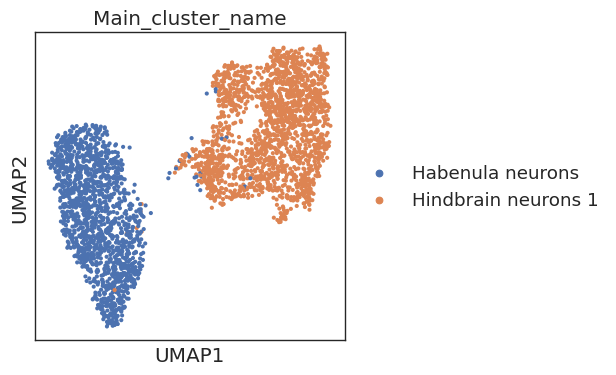

In [53]:
# Let's rerun PCA and UMAP on this adata_subset object and then plot it
sc.tl.pca(adata_subset, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata_subset, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_subset)

# Plot UMAP 
sc.pl.umap(adata_subset, color='Main_cluster_name')

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


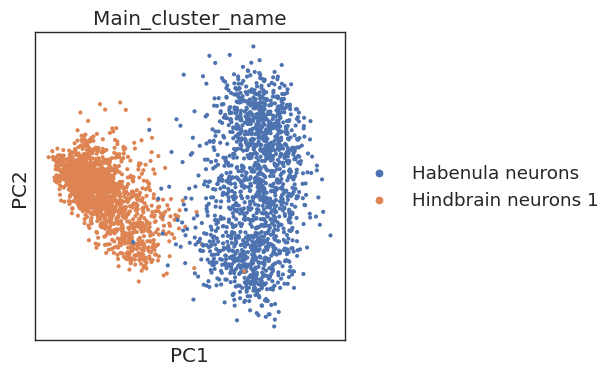

In [56]:
# Print scatter plot using PCs isntead of UMAP
sc.pl.pca(adata_subset, color='Main_cluster_name')

In [57]:
## User defined parameters

## Core parameters 
n_SEACells = num_metacells
build_kernel_on = 'X_pca' # key in ad.obsm to use for computing metacells
                          # This would be replaced by 'X_svd' for ATAC data

## Additional parameters
n_waypoint_eigs = 4 # Number of eigenvalues to consider when initializing metacells

In [58]:
model = SEACells.core.SEACells(adata_subset, 
                  build_kernel_on=build_kernel_on, 
                  n_SEACells=n_SEACells, 
                  n_waypoint_eigs=n_waypoint_eigs,
                  convergence_epsilon = 1e-2)

Welcome to SEACells!


In [59]:
model.construct_kernel_matrix()
M = model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/3395 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/3395 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/3395 [00:00<?, ?it/s]

Constructing CSR matrix...


In [69]:
# Initialize archetypes
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Determing nearest neighbor graph...
Done.
Sampling waypoints ...
Done.
Selecting 45 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 10/10 [00:00<00:00, 137.32it/s]

Selecting 0 cells from greedy initialization.


In [61]:
adata_subset

AnnData object with n_obs × n_vars = 3395 × 55416
    obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Main_cluster_name_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

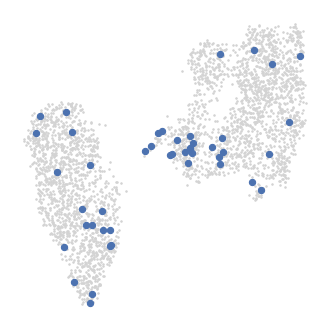

In [70]:
# Plot the initilization to ensure they are spread across phenotypic space
SEACells.plot.plot_initialization(adata_subset, model)

In [71]:
model.fit(min_iter=10, max_iter=50)

Randomly initialized A matrix.
Setting convergence threshold at 1.01434
Starting iteration 1.
Completed iteration 1.
Converged after 4 iterations.
Converged after 5 iterations.
Converged after 6 iterations.
Converged after 7 iterations.
Converged after 8 iterations.
Converged after 9 iterations.
Starting iteration 10.
Completed iteration 10.
Converged after 10 iterations.


In [72]:
# You can force the model to run additional iterations step-wise using the .step() function
print(f'Ran for {len(model.RSS_iters)} iterations')
for _ in range(5):
    model.step()
print(f'Ran for {len(model.RSS_iters)} iterations')

Ran for 11 iterations
Ran for 16 iterations


### Accessing results

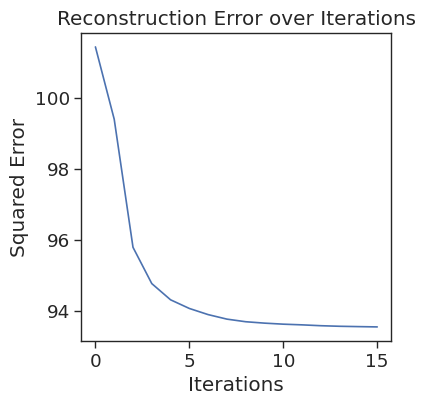

In [73]:
# Check for convergence 
model.plot_convergence()

In [74]:
adata_subset.obs[['SEACell']].head()

,SEACell
index,
cell-0,SEACell-12
cell-1,SEACell-5
cell-2,SEACell-6
cell-3,SEACell-33
cell-4,SEACell-14


In [75]:
# how many cells in each SEACell?
adata_subset.obs['SEACell'].value_counts()

SEACell
SEACell-0     137
SEACell-40    135
SEACell-34    129
SEACell-41    125
SEACell-44    123
SEACell-42    119
SEACell-33    115
SEACell-37    113
SEACell-5     111
SEACell-20    107
SEACell-19    105
SEACell-29    100
SEACell-25     99
SEACell-39     91
SEACell-35     89
SEACell-15     88
SEACell-10     85
SEACell-26     84
SEACell-2      78
SEACell-32     75
SEACell-30     70
SEACell-9      69
SEACell-6      68
SEACell-8      65
SEACell-16     65
SEACell-4      62
SEACell-22     62
SEACell-14     57
SEACell-3      56
SEACell-17     56
SEACell-28     54
SEACell-38     51
SEACell-27     51
SEACell-24     51
SEACell-43     49
SEACell-21     49
SEACell-11     46
SEACell-18     45
SEACell-36     44
SEACell-12     43
SEACell-1      41
SEACell-7      36
SEACell-31     35
SEACell-13     35
SEACell-23     27
Name: count, dtype: int64

In [ ]:
# write code to save adata to file
adata.write('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/Seacells/EasySci.h5ad')